In [2]:
import pandas as pd
import matplotlib.pyplot as plt

paises = pd.read_csv('paises.csv', sep=';', encoding='utf-8-sig')
paises['Country'] = paises['Country'].str.strip()
paises['Region'] = paises['Region'].str.strip()

space = pd.read_csv('space.csv', sep=';', encoding='utf-8-sig')
space['Company Name'] = space['Company Name'].str.strip()


Questão 1

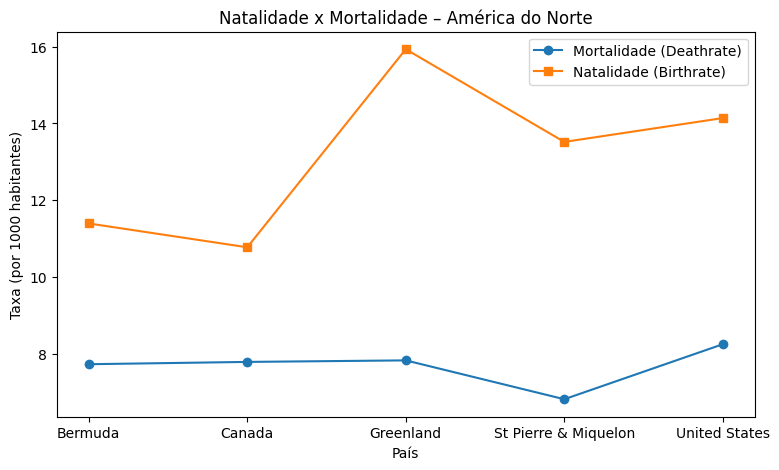

In [10]:
na = paises[paises['Region'] == 'NORTHERN AMERICA']

plt.figure(figsize=(9, 5))
plt.plot(na['Country'], na['Deathrate'], marker='o', label='Mortalidade (Deathrate)')
plt.plot(na['Country'], na['Birthrate'], marker='s', label='Natalidade (Birthrate)')
plt.title('Natalidade x Mortalidade – América do Norte')
plt.xlabel('País')
plt.ylabel('Taxa (por 1000 habitantes)')
plt.legend()
plt.show()


Questão 2

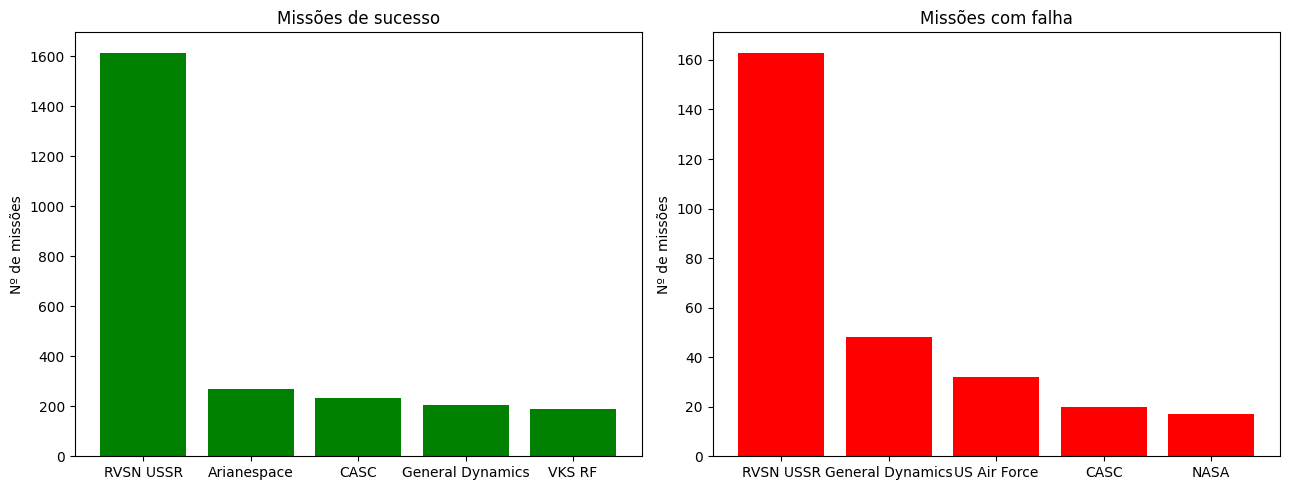

In [17]:
sucesso = space[space['Status Mission'] == 'Success']['Company Name'].value_counts().head(5)
falha = space[space['Status Mission'] != 'Success']['Company Name'].value_counts().head(5)

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.bar(sucesso.index, sucesso.values, color='green')
plt.title('Missões de sucesso')
plt.ylabel('Nº de missões')

plt.subplot(1, 2, 2)
plt.bar(falha.index, falha.values, color='red')
plt.title('Missões com falha')
plt.ylabel('Nº de missões')

plt.tight_layout()
plt.show()


Questão 3

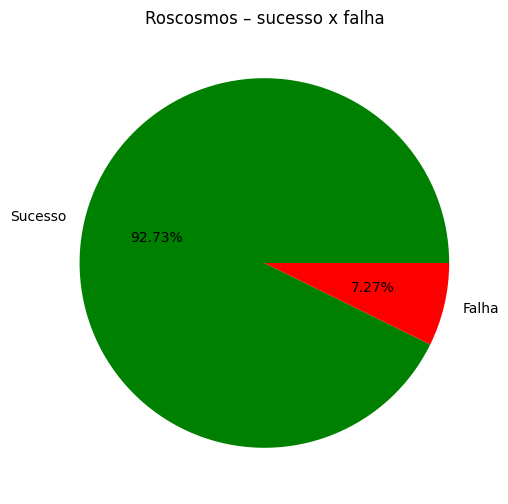

In [22]:
ros = space[space['Company Name'] == 'Roscosmos']
contagem = (ros['Status Mission'].eq('Success').map({True: 'Sucesso', False: 'Falha'}).value_counts())

plt.figure(figsize=(6, 6))
plt.pie(contagem.values, labels=contagem.index, autopct='%1.2f%%', colors=['green', 'red'])
plt.title(f'Roscosmos – sucesso x falha')

plt.show()


Questão 4

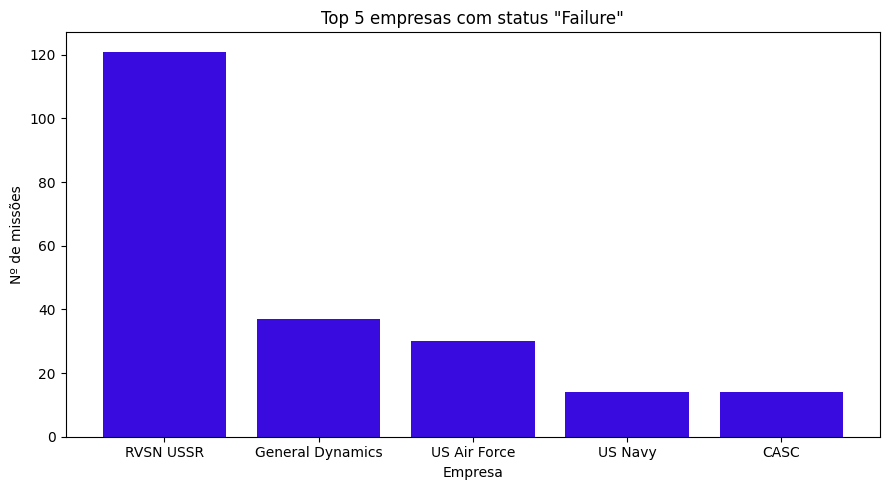

In [26]:
top_fail = space[space['Status Mission'] == 'Failure']['Company Name'].value_counts().head(5)

plt.figure(figsize=(9, 5))
plt.bar(top_fail.index, top_fail.values, color='#3A0BDF')
plt.title('Top 5 empresas com status "Failure"')
plt.xlabel('Empresa')
plt.ylabel('Nº de missões')

plt.tight_layout()
plt.show()

Questão 5

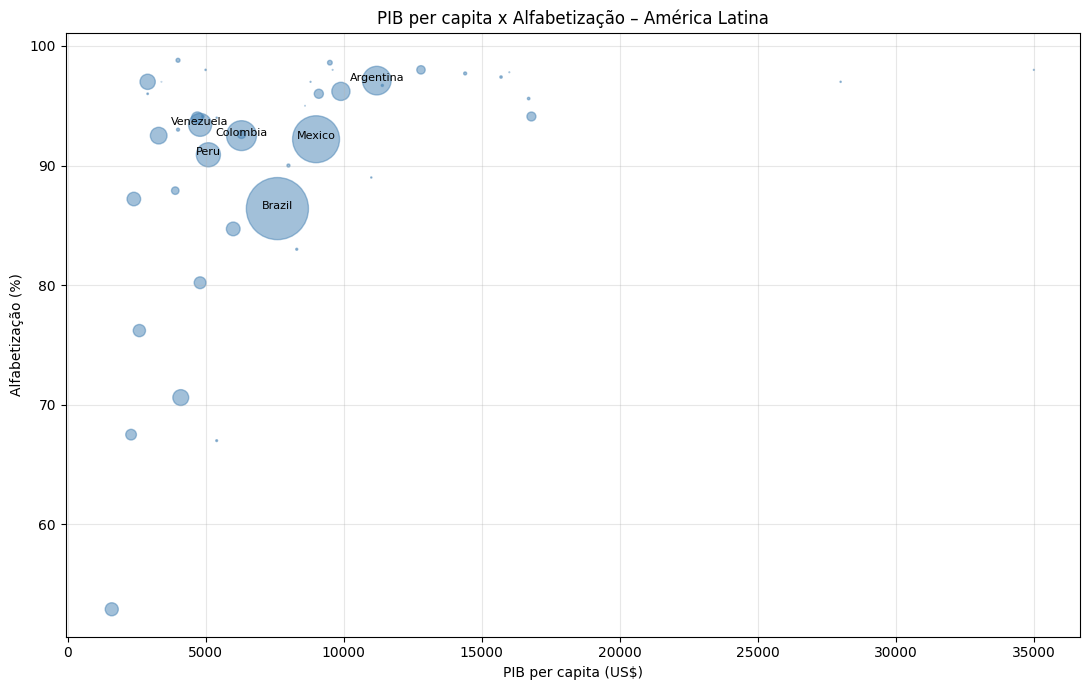

In [31]:
latam = paises[(paises['Region'] == 'LATIN AMER. & CARIB') & (paises['Literacy (%)'] > 0) & (paises['GDP ($ per capita)'] > 0)]

tamanho = latam['Population'] / latam['Population'].max() * 2000

plt.figure(figsize=(11, 7))
plt.scatter(latam['GDP ($ per capita)'], latam['Literacy (%)'], s=tamanho, alpha=0.5, color='steelblue')

for _, r in latam.nlargest(6, 'Population').iterrows():
    plt.annotate(r['Country'], (r['GDP ($ per capita)'], r['Literacy (%)']), ha='center', fontsize=8)

plt.title('PIB per capita x Alfabetização – América Latina')
plt.xlabel('PIB per capita (US$)')
plt.ylabel('Alfabetização (%)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
